# SegFormer — Batch Dataset Inference
Processes all chip folders (`YYYYMMDD`) in the dataset directory.  
Each chip contains `B02.tif`, `B03.tif`, `B04.tif`, `B08.tif`.  
Outputs per-chip cloud cover + irradiance → `results_segformer.csv` + summary plots.

**Run this notebook first, then open `SegFormer_Advanced_Analysis.ipynb`.**

In [1]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import rasterio
import os, re, csv
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from transformers import SegformerForSemanticSegmentation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

C:\Users\matin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Configuration — edit these paths

In [3]:
# ─── EDIT THESE ───────────────────────────────────────────────────────────────
DATASET_DIR   = r"D:\Documents\AEC\FInal Year Project\GHY DATASET 4 years"   # root folder with YYYYMMDD chip folders
MODEL_PATH    = "best_segformer.pth"       # path to trained SegFormer weights
PRETRAINED_ID = "nvidia/mit-b2"            # must match what was used during training
OUTPUT_DIR    = r"D:\Documents\AEC\FInal Year Project\results_segformer"      # where CSV + plots are saved
SAVE_MASKS    = True                       # save per-chip mask PNGs
SAVE_PLOTS    = True                       # save per-chip RGB + mask plots
THRESHOLD     = 0.5                        # cloud probability threshold
I_MAX         = 1000.0                     # max solar irradiance W/m²
ALPHA         = 0.8                        # irradiance attenuation coefficient
# ──────────────────────────────────────────────────────────────────────────────

BANDS = ['B02', 'B03', 'B04', 'B08']

os.makedirs(OUTPUT_DIR, exist_ok=True)
if SAVE_MASKS:
    os.makedirs(os.path.join(OUTPUT_DIR, 'masks'), exist_ok=True)
if SAVE_PLOTS:
    os.makedirs(os.path.join(OUTPUT_DIR, 'plots'), exist_ok=True)

print(f'Dataset : {DATASET_DIR}')
print(f'Output  : {OUTPUT_DIR}')

Dataset : D:\Documents\AEC\FInal Year Project\GHY DATASET 4 years
Output  : D:\Documents\AEC\FInal Year Project\results_segformer


## Model definition — SegFormer

In [4]:
def build_segformer(num_channels=4, num_labels=2, pretrained=PRETRAINED_ID):
    id2label = {0: 'background', 1: 'cloud'}
    label2id = {v: k for k, v in id2label.items()}

    model = SegformerForSemanticSegmentation.from_pretrained(
        pretrained,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    # Patch first Conv2d from 3-ch → 4-ch (add NIR channel)
    old_proj = model.segformer.encoder.patch_embeddings[0].proj
    C_out, _, kH, kW = old_proj.weight.shape
    new_proj = nn.Conv2d(num_channels, C_out, kernel_size=(kH, kW),
                         stride=old_proj.stride, padding=old_proj.padding,
                         bias=(old_proj.bias is not None))
    with torch.no_grad():
        new_proj.weight[:, :3, :, :] = old_proj.weight
        for c in range(3, num_channels):
            new_proj.weight[:, c, :, :] = old_proj.weight.mean(dim=1)
        if old_proj.bias is not None:
            new_proj.bias.copy_(old_proj.bias)
    model.segformer.encoder.patch_embeddings[0].proj = new_proj
    return model


class SegFormerCloud(nn.Module):
    """Returns a single-channel sigmoid probability map at full resolution."""
    def __init__(self, num_channels=4, pretrained=PRETRAINED_ID):
        super().__init__()
        self.segformer = build_segformer(num_channels=num_channels,
                                          pretrained=pretrained)

    def forward(self, x):
        H, W = x.shape[-2:]
        out         = self.segformer(pixel_values=x)
        logits      = out.logits                       # (B, 2, H/4, W/4)
        cloud_logit = logits[:, 1:2, :, :]             # cloud class only
        upsampled   = F.interpolate(cloud_logit, size=(H, W),
                                    mode='bilinear', align_corners=False)
        return torch.sigmoid(upsampled)                # (B, 1, H, W)  ∈ [0,1]

## Load model

In [5]:
model = SegFormerCloud(num_channels=4, pretrained=PRETRAINED_ID)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()
print('✅ SegFormer model loaded')

C:\Users\matin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\matin\.cache\huggingface\hub\models--nvidia--mit-b2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000

✅ SegFormer model loaded


## Helper functions

In [6]:
def load_chip(chip_dir: str):
    """Load B02/B03/B04/B08 from a chip folder. Returns (H,W,4) float32 or None."""
    features = []
    for band in BANDS:
        path = os.path.join(chip_dir, f'{band}.tif')
        if not os.path.isfile(path):
            return None
        with rasterio.open(path) as src:
            features.append(src.read(1).astype(np.float32))
    return np.stack(features, axis=-1)   # (H, W, 4)


def preprocess(image: np.ndarray) -> torch.Tensor:
    """Normalize (same as training) and convert to model-ready tensor."""
    image = image / 65535.0
    image = (image - 0.5) / 0.5
    return torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(device)


def predict(tensor: torch.Tensor, threshold: float = THRESHOLD) -> np.ndarray:
    """Run inference, return binary mask (H, W)."""
    with torch.no_grad():
        prob = model(tensor)   # already sigmoid inside model
        pred = (prob > threshold).float()
    return pred[0, 0].cpu().numpy()


def compute_metrics(mask: np.ndarray, I_max=I_MAX, alpha=ALPHA):
    """Return cloud cover (%) and estimated solar irradiance (W/m²)."""
    cloud_pct  = (np.sum(mask) / mask.size) * 100.0
    irradiance = max(I_max * (1 - alpha * cloud_pct / 100.0), 0.0)
    return cloud_pct, irradiance


def to_rgb(image_4band: np.ndarray) -> np.ndarray:
    """Convert normalised (4,H,W) tensor → display-ready (H,W,3) RGB."""
    rgb = image_4band[[2, 1, 0], :, :]          # B04→R, B03→G, B02→B
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return rgb


def is_chip_folder(name: str) -> bool:
    return bool(re.fullmatch(r'\d{8}', name))


def parse_date(name: str) -> datetime:
    return datetime.strptime(name, '%Y%m%d')


print('✅ Helpers ready')

✅ Helpers ready


## Discover chip folders

In [7]:
all_entries  = sorted(os.listdir(DATASET_DIR))
chip_folders = [
    e for e in all_entries
    if is_chip_folder(e) and os.path.isdir(os.path.join(DATASET_DIR, e))
]

print(f'Found {len(chip_folders)} chip folders')
if chip_folders:
    print(f'  Range : {chip_folders[0]}  →  {chip_folders[-1]}')
    print(f'  Sample: {chip_folders[:5]}')

Found 302 chip folders
  Range : 20220101  →  20251226
  Sample: ['20220101', '20220106', '20220111', '20220116', '20220121']


## Batch inference loop

In [8]:
results = []   # list of dicts → CSV
skipped = []   # chip IDs with missing bands

for chip_id in tqdm(chip_folders, desc='Processing chips'):
    chip_dir = os.path.join(DATASET_DIR, chip_id)

    # ── Load ──────────────────────────────────────────────────────────────────
    image = load_chip(chip_dir)
    if image is None:
        skipped.append(chip_id)
        tqdm.write(f'  ⚠ Skipped {chip_id} — missing band file(s)')
        continue

    # ── Preprocess & predict ──────────────────────────────────────────────────
    tensor = preprocess(image)
    mask   = predict(tensor)

    # ── Metrics ───────────────────────────────────────────────────────────────
    cloud_pct, irradiance = compute_metrics(mask)
    date_obj = parse_date(chip_id)

    results.append({
        'chip_id'        : chip_id,
        'date'           : date_obj.strftime('%Y-%m-%d'),
        'year'           : date_obj.year,
        'month'          : date_obj.month,
        'day'            : date_obj.day,
        'cloud_cover_pct': round(cloud_pct, 4),
        'irradiance_wm2' : round(irradiance, 4),
    })

    # ── Optional: save mask PNG ────────────────────────────────────────────────
    if SAVE_MASKS:
        mask_path = os.path.join(OUTPUT_DIR, 'masks', f'{chip_id}_mask.png')
        plt.imsave(mask_path, mask, cmap='gray')

    # ── Optional: save side-by-side plot ──────────────────────────────────────
    if SAVE_PLOTS:
        img_np = tensor[0].cpu().numpy()
        rgb    = to_rgb(img_np)

        fig, axes = plt.subplots(1, 2, figsize=(11, 5))
        axes[0].imshow(rgb)
        axes[0].set_title(f'RGB — {chip_id}')
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title(
            f'SegFormer Prediction\nCloud: {cloud_pct:.2f}%   Irr: {irradiance:.1f} W/m²'
        )
        axes[1].axis('off')

        plt.tight_layout()
        fig.savefig(
            os.path.join(OUTPUT_DIR, 'plots', f'{chip_id}_result.png'),
            dpi=100, bbox_inches='tight'
        )
        plt.close(fig)

print(f'\n✅ Processed : {len(results)} chips')
print(f'⚠  Skipped   : {len(skipped)} chips {skipped if skipped else ""}')

Processing chips: 100%|██████████████████████████████████████████████████████████████| 302/302 [13:07<00:00,  2.61s/it]


✅ Processed : 302 chips
⚠  Skipped   : 0 chips 


## Save results to CSV

In [9]:
csv_path   = os.path.join(OUTPUT_DIR, 'results_segformer.csv')
fieldnames = ['chip_id', 'date', 'year', 'month', 'day', 'cloud_cover_pct', 'irradiance_wm2']

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f'✅ CSV saved → {csv_path}')
print(f'\nFirst 5 rows:')
for r in results[:5]:
    print(f"  {r['date']}  CC={r['cloud_cover_pct']:.2f}%  Irr={r['irradiance_wm2']:.1f} W/m²")

✅ CSV saved → D:\Documents\AEC\FInal Year Project\results_segformer\results_segformer.csv

First 5 rows:
  2022-01-01  CC=98.55%  Irr=211.6 W/m²
  2022-01-06  CC=11.93%  Irr=904.6 W/m²
  2022-01-11  CC=100.00%  Irr=200.0 W/m²
  2022-01-16  CC=99.51%  Irr=203.9 W/m²
  2022-01-21  CC=100.00%  Irr=200.0 W/m²


## Summary plots

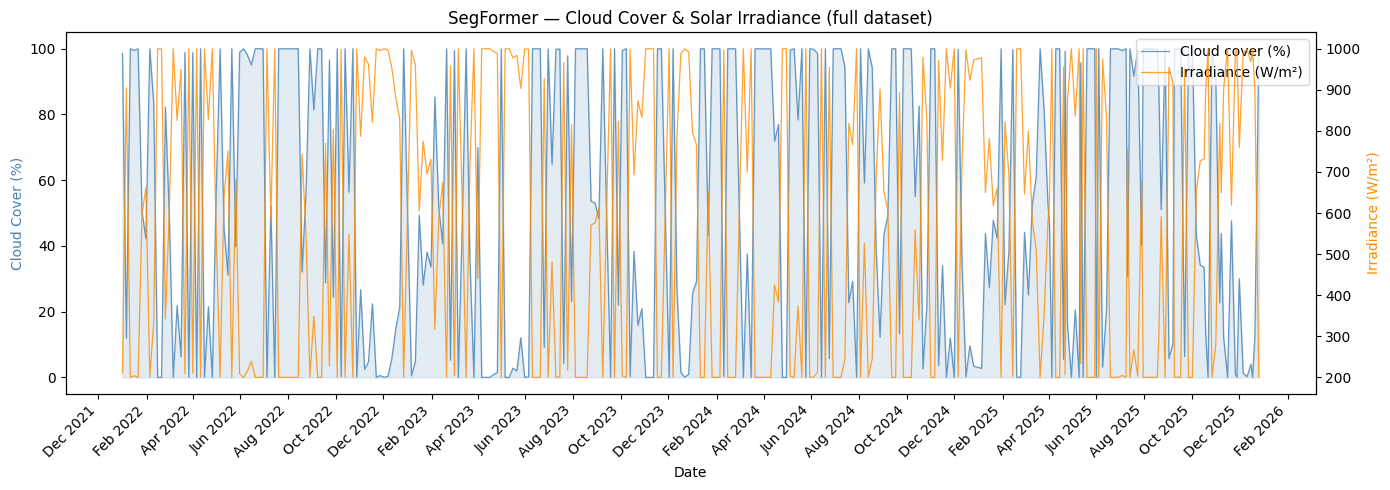

✅ Plot 1 saved


In [10]:
import numpy as np

dates      = [datetime.strptime(r['date'], '%Y-%m-%d') for r in results]
cloud_vals = [r['cloud_cover_pct'] for r in results]
irr_vals   = [r['irradiance_wm2']  for r in results]
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# ── Plot 1: Time-series dual y-axis ──────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(dates, cloud_vals, color='steelblue', linewidth=0.9, alpha=0.8, label='Cloud cover (%)')
ax1.fill_between(dates, cloud_vals, alpha=0.15, color='steelblue')
ax2.plot(dates, irr_vals,  color='darkorange', linewidth=0.9, alpha=0.8, label='Irradiance (W/m²)')

ax1.set_ylabel('Cloud Cover (%)',    color='steelblue')
ax2.set_ylabel('Irradiance (W/m²)', color='darkorange')
ax1.set_xlabel('Date')
ax1.set_title('SegFormer — Cloud Cover & Solar Irradiance (full dataset)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'timeseries_cloud_irradiance.png'), dpi=150)
plt.show()
print('✅ Plot 1 saved')

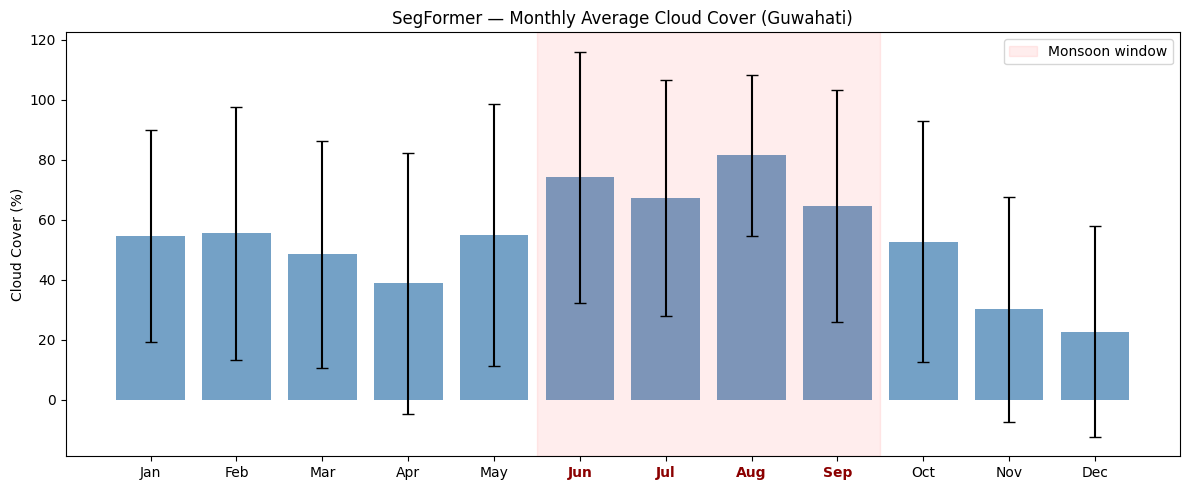

✅ Plot 2 saved


In [11]:
# ── Plot 2: Monthly average cloud cover bar ───────────────────────────────────
monthly_cloud = {m: [] for m in range(1, 13)}
monthly_irr   = {m: [] for m in range(1, 13)}

for r in results:
    monthly_cloud[r['month']].append(r['cloud_cover_pct'])
    monthly_irr[r['month']].append(r['irradiance_wm2'])

avg_cloud = [np.mean(monthly_cloud[m]) if monthly_cloud[m] else 0 for m in range(1, 13)]
std_cloud = [np.std(monthly_cloud[m])  if monthly_cloud[m] else 0 for m in range(1, 13)]

x = np.arange(12)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, avg_cloud, color='steelblue', alpha=0.75, yerr=std_cloud, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Cloud Cover (%)')
ax.set_title('SegFormer — Monthly Average Cloud Cover (Guwahati)')

for i in [5, 6, 7, 8]:
    ax.get_xticklabels()[i].set_color('darkred')
    ax.get_xticklabels()[i].set_fontweight('bold')
ax.axvspan(4.5, 8.5, alpha=0.07, color='red', label='Monsoon window')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_avg_cloud_cover.png'), dpi=150)
plt.show()
print('✅ Plot 2 saved')

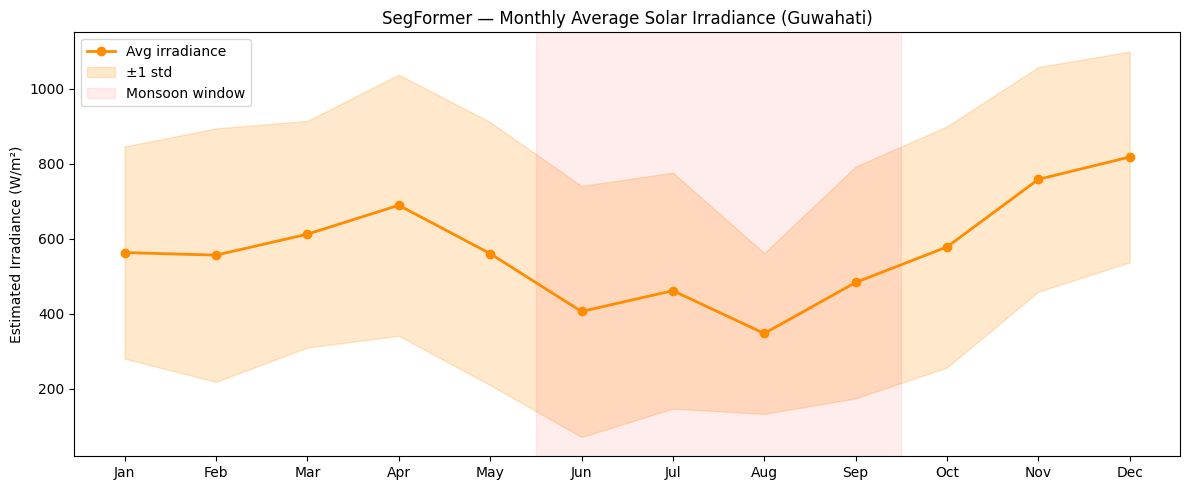

✅ Plot 3 saved


In [12]:
# ── Plot 3: Monthly average irradiance line ───────────────────────────────────
avg_irr     = np.array([np.mean(monthly_irr[m]) if monthly_irr[m] else 0 for m in range(1, 13)])
std_irr     = np.array([np.std(monthly_irr[m])  if monthly_irr[m] else 0 for m in range(1, 13)])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, avg_irr, color='darkorange', marker='o', linewidth=2, label='Avg irradiance')
ax.fill_between(x, avg_irr - std_irr, avg_irr + std_irr,
                alpha=0.2, color='darkorange', label='±1 std')
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Estimated Irradiance (W/m²)')
ax.set_title('SegFormer — Monthly Average Solar Irradiance (Guwahati)')
ax.axvspan(4.5, 8.5, alpha=0.07, color='red', label='Monsoon window')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_avg_irradiance.png'), dpi=150)
plt.show()
print('✅ Plot 3 saved')

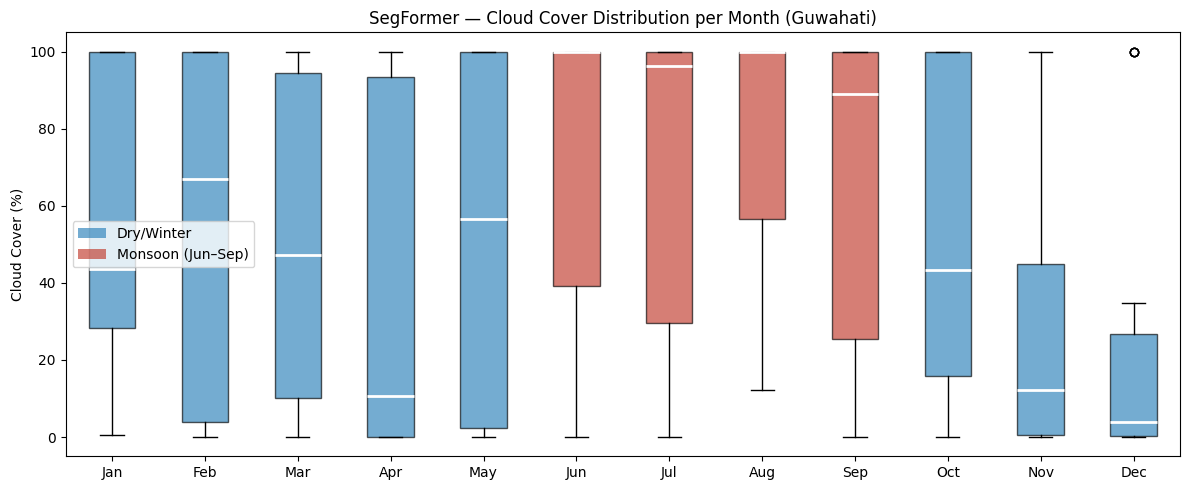

✅ Plot 4 saved


In [13]:
# ── Plot 4: Monthly cloud cover box plots ─────────────────────────────────────
box_data = [monthly_cloud[m] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#c0392b' if i in [5, 6, 7, 8] else '#2980b9')
    patch.set_alpha(0.65)

ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Cloud Cover (%)')
ax.set_title('SegFormer — Cloud Cover Distribution per Month (Guwahati)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2980b9', alpha=0.65, label='Dry/Winter'),
    Patch(facecolor='#c0392b', alpha=0.65, label='Monsoon (Jun–Sep)'),
])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_boxplot_cloud.png'), dpi=150)
plt.show()
print('✅ Plot 4 saved')

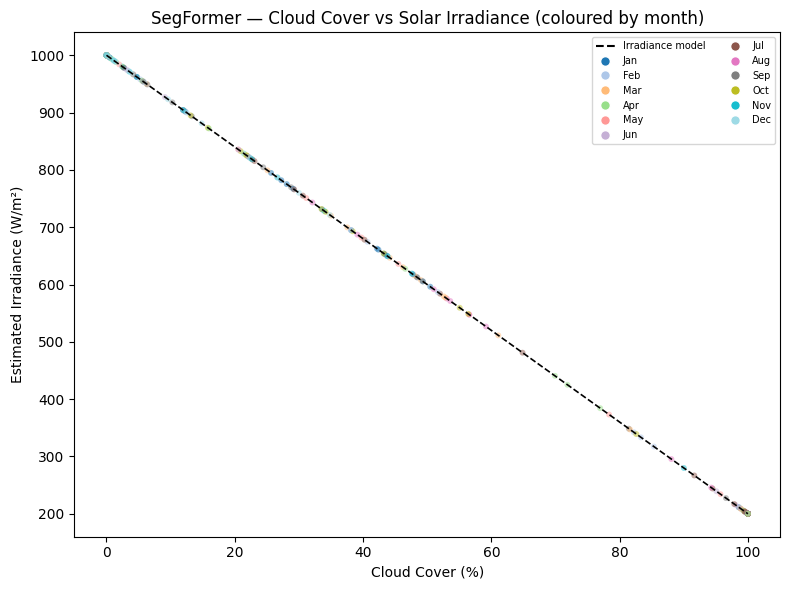

✅ Plot 5 saved


In [14]:
# ── Plot 5: Scatter cloud cover vs irradiance ─────────────────────────────────
month_colors    = plt.cm.tab20(np.linspace(0, 1, 12))
month_color_map = {m+1: month_colors[m] for m in range(12)}

fig, ax = plt.subplots(figsize=(8, 6))
for r in results:
    ax.scatter(r['cloud_cover_pct'], r['irradiance_wm2'],
               color=month_color_map[r['month']], alpha=0.5, s=18, edgecolors='none')

cc_line  = np.linspace(0, 100, 200)
irr_line = I_MAX * (1 - ALPHA * cc_line / 100)
ax.plot(cc_line, irr_line, 'k--', linewidth=1.2,
        label=f'Model: I = {I_MAX}×(1−{ALPHA}×CC)')

from matplotlib.lines import Line2D
legend_els  = [Line2D([0],[0], color='k', linestyle='--', label='Irradiance model')]
legend_els += [Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=month_color_map[m], markersize=7,
                       label=MONTH_NAMES[m-1]) for m in range(1, 13)]
ax.legend(handles=legend_els, fontsize=7, ncol=2, loc='upper right')
ax.set_xlabel('Cloud Cover (%)')
ax.set_ylabel('Estimated Irradiance (W/m²)')
ax.set_title('SegFormer — Cloud Cover vs Solar Irradiance (coloured by month)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_cloud_vs_irradiance.png'), dpi=150)
plt.show()
print('✅ Plot 5 saved')

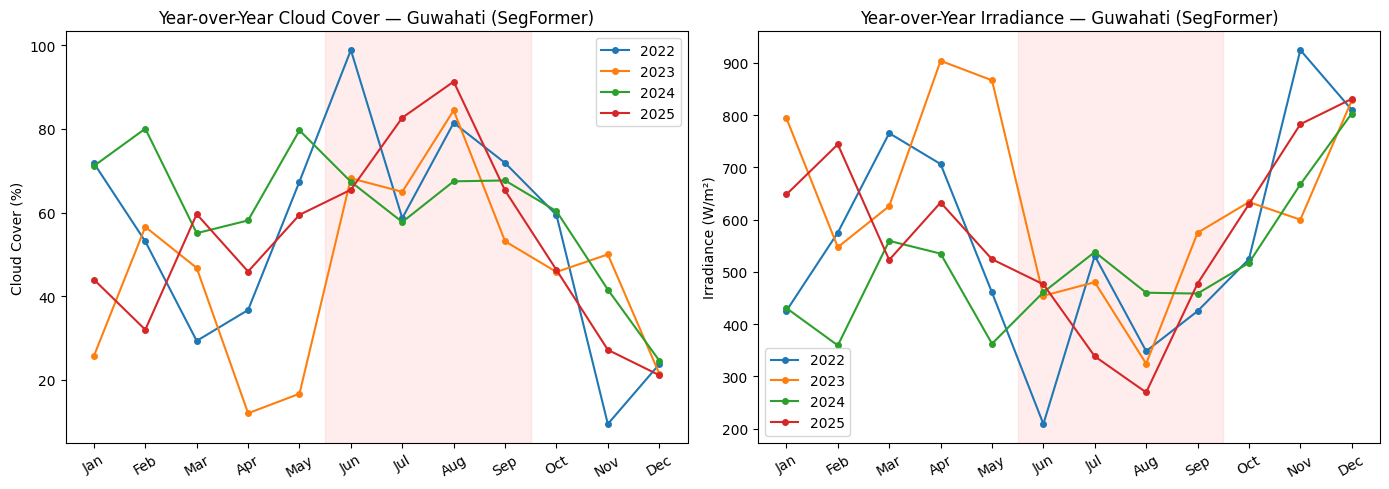

✅ Plot 6 saved


In [15]:
# ── Plot 6: Year-over-year comparison ────────────────────────────────────────
years = sorted(set(r['year'] for r in results))

if len(years) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for yr in years:
        yr_results       = [r for r in results if r['year'] == yr]
        yr_monthly_cloud = {m: [] for m in range(1, 13)}
        yr_monthly_irr   = {m: [] for m in range(1, 13)}
        for r in yr_results:
            yr_monthly_cloud[r['month']].append(r['cloud_cover_pct'])
            yr_monthly_irr[r['month']].append(r['irradiance_wm2'])

        yr_avg_cloud = [np.mean(yr_monthly_cloud[m]) if yr_monthly_cloud[m] else np.nan for m in range(1, 13)]
        yr_avg_irr   = [np.mean(yr_monthly_irr[m])   if yr_monthly_irr[m]   else np.nan for m in range(1, 13)]

        axes[0].plot(range(12), yr_avg_cloud, marker='o', markersize=4, linewidth=1.5, label=str(yr))
        axes[1].plot(range(12), yr_avg_irr,   marker='o', markersize=4, linewidth=1.5, label=str(yr))

    for ax, title, ylabel in zip(
        axes,
        ['Year-over-Year Cloud Cover — Guwahati (SegFormer)',
         'Year-over-Year Irradiance — Guwahati (SegFormer)'],
        ['Cloud Cover (%)', 'Irradiance (W/m²)']
    ):
        ax.set_xticks(range(12))
        ax.set_xticklabels(MONTH_NAMES, rotation=30)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        ax.axvspan(4.5, 8.5, alpha=0.07, color='red')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'year_over_year_comparison.png'), dpi=150)
    plt.show()
    print('✅ Plot 6 saved')
else:
    print('ℹ Only one year in dataset — skipping year-over-year plot')

In [16]:
# ── Console summary ───────────────────────────────────────────────────────────
all_cc  = np.array(cloud_vals)
all_irr = np.array(irr_vals)

print('=' * 50)
print('DATASET SUMMARY — Guwahati (SegFormer)')
print('=' * 50)
print(f'Total chips processed : {len(results)}')
print(f'Date range            : {dates[0].date()}  →  {dates[-1].date()}')
print()
print('Cloud Cover (%)')
print(f'  Mean   : {all_cc.mean():.2f}')
print(f'  Median : {np.median(all_cc):.2f}')
print(f'  Std    : {all_cc.std():.2f}')
print(f'  Min    : {all_cc.min():.2f}')
print(f'  Max    : {all_cc.max():.2f}')
print()
print('Solar Irradiance (W/m²)')
print(f'  Mean   : {all_irr.mean():.2f}')
print(f'  Median : {np.median(all_irr):.2f}')
print(f'  Std    : {all_irr.std():.2f}')
print(f'  Min    : {all_irr.min():.2f}')
print(f'  Max    : {all_irr.max():.2f}')
print()
print(f'Output directory : {OUTPUT_DIR}')
print(f'CSV results      : {csv_path}')
print()
print('👉 Now open SegFormer_Advanced_Analysis.ipynb')

DATASET SUMMARY — Guwahati (SegFormer)
Total chips processed : 302
Date range            : 2022-01-01  →  2025-12-26

Cloud Cover (%)
  Mean   : 53.93
  Median : 49.17
  Std    : 42.16
  Min    : 0.00
  Max    : 100.00

Solar Irradiance (W/m²)
  Mean   : 568.59
  Median : 606.66
  Std    : 337.29
  Min    : 200.00
  Max    : 1000.00

Output directory : D:\Documents\AEC\FInal Year Project\results_segformer
CSV results      : D:\Documents\AEC\FInal Year Project\results_segformer\results_segformer.csv

👉 Now open SegFormer_Advanced_Analysis.ipynb
